# Q5 model comparison

This notebook compares four one-year-ahead forecasting methods for the survey-weighted frequent sport volunteering rate:

- Naive baseline;
- Ridge Regression;
- Random Forest;
- Gradient Boosting.

Three borough-level forecasting tasks are evaluated separately:

- borough × age × activity level;
- borough × age;
- borough × activity level.

Formal model and hyperparameter selection uses three expanding rolling-origin folds:

- Years 3–4 predict Year 5;
- Years 3–5 predict Year 6;
- Years 3–6 predict Year 7.

Candidates are ranked by the mean effective-n-weighted Total Variation error across the three validation years. For the binary frequent-versus-not-frequent volunteering outcome, Total Variation is exactly equal to the absolute error in the frequent-volunteering rate.

Year 8 is retained as an untouched independent test and cannot alter the validation choice.

> **Interpretation boundary.**
> The target is a survey-weighted cell estimate rather than an individual-level outcome. Effective sample size is therefore used in the formal validation score to give greater influence to more precise survey estimates, while subgroup and reliability diagnostics are retained to show performance in sparse cells.

## 1 — Load and validate the three complete panels

The three panel structures are loaded from the dataset notebook. Each task uses the same historical years, target definition and candidate model families, but the subgroup structure differs.

Year 8 is loaded with the historical panel but remains excluded from all model and hyperparameter selection.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

pd.set_option(
    "display.max_columns",
    100,
)

PROJECT_DIR = Path(
    "/Users/zsh/Downloads/PROJECT/code"
)

DATASET_DIR = (
    PROJECT_DIR
    / "q4_dataset_outputs"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "q4_model_comparison_outputs"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

TABLE_DIR = (
    OUTPUT_DIR
    / "tables"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET = "frequent_volunteer_rate"
LAG_FEATURE = "frequent_volunteer_rate_lag1"

HISTORICAL_YEARS = [
    3,
    4,
    5,
    6,
    7,
    8,
]

CV_FOLDS = [
    {
        "train_end_year": 4,
        "validation_year": 5,
    },
    {
        "train_end_year": 5,
        "validation_year": 6,
    },
    {
        "train_end_year": 6,
        "validation_year": 7,
    },
]

TEST_YEAR = 8

RANDOM_STATE = 2026

MODEL_NAMES = [
    "Naive baseline",
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
]

MODEL_COMPLEXITY_ORDER = {
    "Naive baseline": 0,
    "Ridge Regression": 1,
    "Random Forest": 2,
    "Gradient Boosting": 3,
}

TASK_CONFIG = {
    "borough_age_activity": {
        "label": (
            "Borough-age-activity"
        ),
        "path": (
            DATASET_DIR
            / "q5_versionA_borough_age_activitylevel_panel_complete.csv"
        ),
        "expected_rows": 4608,
        "expected_series": 768,
    },
    "borough_age": {
        "label": "Borough-age",
        "path": (
            DATASET_DIR
            / "q5_versionA_borough_age_panel_complete.csv"
        ),
        "expected_rows": 1536,
        "expected_series": 256,
    },
    "borough_activity": {
        "label": "Borough-activity",
        "path": (
            DATASET_DIR
            / "q5_versionA_borough_activitylevel_panel_complete.csv"
        ),
        "expected_rows": 576,
        "expected_series": 96,
    },
}

In [2]:
def parse_nullable_boolean(series):
    text_values = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return text_values.map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    ).astype("boolean")


def load_complete_panel(
    task_name,
    config,
):
    panel_path = config["path"]

    if not panel_path.exists():
        raise FileNotFoundError(
            f"File not found: {panel_path}"
        )

    panel = pd.read_csv(
        panel_path,
        low_memory=False,
    )

    required_columns = [
        "series_id",
        "year",
        "LA_2023",
        TARGET,
        "effective_n_parent_cell",
        "small_cell",
        "cell_observed",
    ]

    if task_name in [
        "borough_age_activity",
        "borough_age",
    ]:
        required_columns.extend(
            [
                "age_group_code",
                "age_group",
            ]
        )

    if task_name in [
        "borough_age_activity",
        "borough_activity",
    ]:
        required_columns.extend(
            [
                "activity_level_3cat",
                "activity_level_3cat_label",
            ]
        )

    missing_columns = [
        column
        for column in required_columns
        if column not in panel.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{task_name} is missing columns: {missing_columns}"
        )

    numeric_columns = [
        "year",
        "LA_2023",
        TARGET,
        "effective_n_parent_cell",
    ]

    for column in [
        "age_group_code",
        "activity_level_3cat",
    ]:
        if column in panel.columns:
            numeric_columns.append(
                column
            )

    for column in numeric_columns:
        panel[column] = pd.to_numeric(
            panel[column],
            errors="coerce",
        )

    for column in [
        "small_cell",
        "cell_observed",
    ]:
        panel[column] = (
            parse_nullable_boolean(
                panel[column]
            )
        )

    if len(panel) != config[
        "expected_rows"
    ]:
        raise ValueError(
            f"{task_name} has an unexpected row count"
        )

    if panel[
        "series_id"
    ].nunique() != config[
        "expected_series"
    ]:
        raise ValueError(
            f"{task_name} has an unexpected number of series"
        )

    if sorted(
        panel["year"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    ) != HISTORICAL_YEARS:
        raise ValueError(
            f"{task_name} contains unexpected years"
        )

    if panel.duplicated(
        subset=[
            "series_id",
            "year",
        ]
    ).any():
        raise ValueError(
            f"{task_name} contains duplicate series-year rows"
        )

    series_lengths = (
        panel
        .groupby("series_id")
        .size()
    )

    if not series_lengths.eq(6).all():
        raise ValueError(
            f"{task_name} series do not all contain six rows"
        )

    observed = panel[
        TARGET
    ].notna()

    if not panel.loc[
        observed,
        TARGET,
    ].between(
        0,
        1,
    ).all():
        raise ValueError(
            f"{task_name} contains an invalid target rate"
        )

    if not panel.loc[
        observed,
        "effective_n_parent_cell",
    ].gt(0).all():
        raise ValueError(
            f"{task_name} contains an invalid effective sample size"
        )

    return panel


panels = {}

for task_name, config in (
    TASK_CONFIG.items()
):
    panels[task_name] = (
        load_complete_panel(
            task_name=task_name,
            config=config,
        )
    )

    print(
        f"{config['label']}: {len(panels[task_name]):,} rows, "
        f"{panels[task_name][TARGET].notna().sum():,} observed targets"
    )

Borough-age-activity: 4,608 rows, 4,290 observed targets
Borough-age: 1,536 rows, 1,523 observed targets
Borough-activity: 576 rows, 576 observed targets


## 2 — Create the fixed feature sets

All three tasks use the same three historical predictors:

- the same series' previous-year frequent-volunteering rate;
- an indicator showing whether the previous-year rate is unavailable;
- a linear time trend.

Borough identity is included as a categorical predictor in every task.

The subgroup predictor depends on the task:

- borough–age–activity uses one combined age–activity category so that activity-level differences can vary by age group;
- borough–age uses age group;
- borough–activity uses activity level.

Effective sample size and small-cell status are retained for evaluation only and are not used as behavioural predictors.

In [3]:
def prepare_model_panel(
    panel,
    task_name,
):
    result = (
        panel
        .sort_values(
            [
                "series_id",
                "year",
            ]
        )
        .reset_index(drop=True)
        .copy()
    )

    result[
        LAG_FEATURE
    ] = (
        result
        .groupby(
            "series_id",
            sort=False,
        )[TARGET]
        .shift(1)
    )

    result[
        "lag_1_available"
    ] = result[
        LAG_FEATURE
    ].notna()

    result[
        "lag_1_missing"
    ] = (
        ~result[
            "lag_1_available"
        ]
    ).astype(int)

    result[
        "time_trend"
    ] = (
        result["year"]
        - min(
            HISTORICAL_YEARS
        )
    )

    result[
        "borough_category"
    ] = (
        result[
            "LA_2023"
        ]
        .astype("Int64")
        .astype("string")
    )

    if task_name == (
        "borough_age_activity"
    ):
        result[
            "age_activity_group"
        ] = (
            result[
                "age_group"
            ].astype("string")
            + "__"
            + result[
                "activity_level_3cat_label"
            ].astype("string")
        )

    elif task_name == (
        "borough_age"
    ):
        result[
            "age_group_category"
        ] = (
            result[
                "age_group"
            ].astype("string")
        )

    elif task_name == (
        "borough_activity"
    ):
        result[
            "activity_category"
        ] = (
            result[
                "activity_level_3cat_label"
            ].astype("string")
        )

    result[
        "target_available"
    ] = result[
        TARGET
    ].notna()

    return result


model_panels = {
    task_name: (
        prepare_model_panel(
            panel=panel,
            task_name=task_name,
        )
    )
    for task_name, panel
    in panels.items()
}

NUMERIC_FEATURES = [
    LAG_FEATURE,
    "lag_1_missing",
    "time_trend",
]

FEATURE_CONFIG = {
    "borough_age_activity": {
        "numeric": (
            NUMERIC_FEATURES
        ),
        "categorical": [
            "borough_category",
            "age_activity_group",
        ],
    },
    "borough_age": {
        "numeric": (
            NUMERIC_FEATURES
        ),
        "categorical": [
            "borough_category",
            "age_group_category",
        ],
    },
    "borough_activity": {
        "numeric": (
            NUMERIC_FEATURES
        ),
        "categorical": [
            "borough_category",
            "activity_category",
        ],
    },
}

feature_summary_rows = []

for task_name, panel in (
    model_panels.items()
):
    observed = panel[
        "target_available"
    ]

    feature_summary_rows.append(
        {
            "task": task_name,
            "observed_targets": int(
                observed.sum()
            ),
            "observed_targets_with_lag": int(
                panel.loc[
                    observed,
                    "lag_1_available",
                ].sum()
            ),
            "numeric_features": (
                ", ".join(
                    FEATURE_CONFIG[
                        task_name
                    ]["numeric"]
                )
            ),
            "categorical_features": (
                ", ".join(
                    FEATURE_CONFIG[
                        task_name
                    ]["categorical"]
                )
            ),
        }
    )

feature_summary = pd.DataFrame(
    feature_summary_rows
)

display(
    feature_summary
)

,task,observed_targets,observed_targets_with_lag,numeric_features,categorical_features
0,borough_age_activity,4290,3417,"frequent_volunteer_rate_lag1, lag_1_missing, t...","borough_category, age_activity_group"
1,borough_age,1523,1256,"frequent_volunteer_rate_lag1, lag_1_missing, t...","borough_category, age_group_category"
2,borough_activity,576,480,"frequent_volunteer_rate_lag1, lag_1_missing, t...","borough_category, activity_category"


## 3 — Rolling-origin evaluation and primary metric

The formal comparison uses three one-year-ahead rolling validation folds.

Within each validation year, all four forecasting methods are evaluated on the same lag-available cells. This common sample is required because the Naive baseline cannot predict a cell when the previous-year rate is missing.

For each validation cell, the row-level Total Variation error is:

$$
TV_i = |y_i - \hat{y}_i|
$$

The formal fold score is the effective-sample-size weighted mean:

$$
TV_{w,f} = \frac{\sum_i n_{\mathrm{eff},i} TV_i}{\sum_i n_{\mathrm{eff},i}}
$$

The three validation years then contribute equally to the final selection score:

$$
CVScore = \frac{TV_{w,5} + TV_{w,6} + TV_{w,7}}{3}
$$

Unweighted MAE, RMSE, weighted RMSE, out-of-sample \(R^2\), mean error and clipping are retained as supporting diagnostics.

In [4]:
def weighted_average(
    values,
    weights,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not valid.any():
        return np.nan

    return np.average(
        values[valid],
        weights=weights[valid],
    )


def score_prediction_table(
    prediction_table,
    common_only=True,
):
    evaluation = (
        prediction_table
        .loc[
            prediction_table[
                TARGET
            ].notna()
        ]
        .copy()
    )

    if common_only:
        evaluation = (
            evaluation.loc[
                evaluation[
                    "lag_1_available"
                ]
            ]
            .copy()
        )

    valid = (
        evaluation[
            "predicted_rate"
        ].notna()
        & evaluation[
            "raw_predicted_rate"
        ].notna()
        & evaluation[
            "effective_n_parent_cell"
        ].notna()
        & (
            evaluation[
                "effective_n_parent_cell"
            ]
            > 0
        )
    )

    evaluation = (
        evaluation.loc[
            valid
        ]
        .copy()
    )

    if len(evaluation) == 0:
        raise ValueError(
            "No valid rows were available for evaluation"
        )

    evaluation[
        "row_tv"
    ] = (
        evaluation[TARGET]
        - evaluation[
            "predicted_rate"
        ]
    ).abs()

    evaluation[
        "squared_error"
    ] = (
        evaluation[TARGET]
        - evaluation[
            "predicted_rate"
        ]
    ) ** 2

    evaluation[
        "prediction_error"
    ] = (
        evaluation[
            "predicted_rate"
        ]
        - evaluation[TARGET]
    )

    clipped = (
        (
            evaluation[
                "raw_predicted_rate"
            ]
            < 0
        )
        | (
            evaluation[
                "raw_predicted_rate"
            ]
            > 1
        )
    )

    if (
        len(evaluation) < 2
        or np.isclose(
            evaluation[
                TARGET
            ].var(),
            0,
        )
    ):
        r2 = np.nan

    else:
        r2 = r2_score(
            evaluation[TARGET],
            evaluation[
                "predicted_rate"
            ],
        )

    weighted_mse = (
        weighted_average(
            evaluation[
                "squared_error"
            ],
            evaluation[
                "effective_n_parent_cell"
            ],
        )
    )

    return {
        "observations": len(
            evaluation
        ),
        "weighted_tv": (
            weighted_average(
                evaluation[
                    "row_tv"
                ],
                evaluation[
                    "effective_n_parent_cell"
                ],
            )
        ),
        "mae": mean_absolute_error(
            evaluation[TARGET],
            evaluation[
                "predicted_rate"
            ],
        ),
        "rmse": np.sqrt(
            mean_squared_error(
                evaluation[TARGET],
                evaluation[
                    "predicted_rate"
                ],
            )
        ),
        "weighted_rmse": (
            np.sqrt(
                weighted_mse
            )
        ),
        "r2": r2,
        "mean_error": (
            evaluation[
                "prediction_error"
            ].mean()
        ),
        "clipped_predictions": int(
            clipped.sum()
        ),
        "clip_rate": (
            clipped.mean()
        ),
    }

## 4 — Candidate models and hyperparameters

The candidate model families are shared across the three tasks, but the parameter grid is tailored to the Q5 data rather than copied directly from another research question.

Ridge Regression uses a broad logarithmic regularisation grid because one-hot encoded borough and subgroup predictors create many correlated coefficients, while the optimal regularisation strength is not known in advance.

Random Forest uses a fixed number of trees and a small set of interpretable depth, leaf-size and feature-subsampling profiles. Leaf size is defined as a proportion of the training sample, with a minimum of five rows, because the three panel structures contain very different numbers of observations.

Gradient Boosting is restricted mainly to shallow trees because the historical series contain only six annual waves and the detailed borough–age–activity panel remains noisy. Huber loss is emphasised because extreme weighted cell rates are common in sparse cells; one otherwise comparable squared-error candidate is retained to check whether the robust loss is unnecessarily restrictive.

The grid is deliberately compact because only three validation years are available.

In [5]:
MODEL_PARAMETER_GRID = {
    "Naive baseline": [
        {}
    ],
    "Ridge Regression": [
        {
            "alpha": alpha
        }
        for alpha in [
            0.01,
            0.1,
            1.0,
            10.0,
            100.0,
            1000.0,
            10000.0,
        ]
    ],
    "Random Forest": [
        {
            "n_estimators": 250,
            "max_depth": 4,
            "min_leaf_fraction": 0.05,
            "max_features": 0.5,
        },
        {
            "n_estimators": 250,
            "max_depth": 6,
            "min_leaf_fraction": 0.02,
            "max_features": 0.5,
        },
        {
            "n_estimators": 250,
            "max_depth": 8,
            "min_leaf_fraction": 0.01,
            "max_features": 0.5,
        },
        {
            "n_estimators": 250,
            "max_depth": None,
            "min_leaf_fraction": 0.02,
            "max_features": 0.8,
        },
        {
            "n_estimators": 250,
            "max_depth": None,
            "min_leaf_fraction": 0.01,
            "max_features": 0.8,
        },
    ],
    "Gradient Boosting": [
        {
            "n_estimators": 120,
            "learning_rate": 0.05,
            "max_depth": 1,
            "min_leaf_fraction": 0.05,
            "loss": "huber",
        },
        {
            "n_estimators": 150,
            "learning_rate": 0.05,
            "max_depth": 2,
            "min_leaf_fraction": 0.02,
            "loss": "huber",
        },
        {
            "n_estimators": 250,
            "learning_rate": 0.025,
            "max_depth": 2,
            "min_leaf_fraction": 0.02,
            "loss": "huber",
        },
        {
            "n_estimators": 400,
            "learning_rate": 0.01,
            "max_depth": 2,
            "min_leaf_fraction": 0.02,
            "loss": "huber",
        },
        {
            "n_estimators": 150,
            "learning_rate": 0.05,
            "max_depth": 3,
            "min_leaf_fraction": 0.02,
            "loss": "huber",
        },
        {
            "n_estimators": 150,
            "learning_rate": 0.05,
            "max_depth": 2,
            "min_leaf_fraction": 0.02,
            "loss": "squared_error",
        },
    ],
}

parameter_count_summary = pd.DataFrame(
    {
        "model": MODEL_NAMES,
        "candidate_parameters": [
            len(
                MODEL_PARAMETER_GRID[
                    model_name
                ]
            )
            for model_name
            in MODEL_NAMES
        ],
    }
)

display(
    parameter_count_summary
)

,model,candidate_parameters
0,Naive baseline,1
1,Ridge Regression,7
2,Random Forest,5
3,Gradient Boosting,6


## 5 — Model and prediction helpers

Machine-learning models are fitted on every available target row in the training years. Missing lag values are handled inside the pipeline by median imputation, and the lag-missing indicator records this explicitly.

The formal comparison still uses only the common lag-available validation sample so that Naive and machine-learning models are compared on identical cells.

Predicted rates are clipped to the valid interval \([0,1]\), while the unclipped prediction is retained to diagnose extrapolation outside the valid range.

In [6]:
def resolve_tree_parameters(
    parameters,
    training_rows,
):
    resolved = (
        parameters.copy()
    )

    leaf_fraction = (
        resolved.pop(
            "min_leaf_fraction"
        )
    )

    resolved[
        "min_samples_leaf"
    ] = max(
        5,
        int(
            np.ceil(
                leaf_fraction
                * training_rows
            )
        ),
    )

    return resolved


def build_preprocessor(
    model_name,
    numeric_features,
    categorical_features,
):
    numeric_steps = [
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        )
    ]

    if model_name == (
        "Ridge Regression"
    ):
        numeric_steps.append(
            (
                "scaler",
                StandardScaler(),
            )
        )

    numeric_transformer = (
        Pipeline(
            steps=numeric_steps
        )
    )

    categorical_transformer = (
        Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(
                        strategy=(
                            "most_frequent"
                        )
                    ),
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown=(
                            "ignore"
                        ),
                        sparse_output=False,
                    ),
                ),
            ]
        )
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_transformer,
                numeric_features,
            ),
            (
                "categorical",
                categorical_transformer,
                categorical_features,
            ),
        ],
        remainder="drop",
    )


def build_model(
    model_name,
    parameters,
    numeric_features,
    categorical_features,
    training_rows,
    random_state=RANDOM_STATE,
):
    preprocessor = (
        build_preprocessor(
            model_name=model_name,
            numeric_features=(
                numeric_features
            ),
            categorical_features=(
                categorical_features
            ),
        )
    )

    if model_name == (
        "Ridge Regression"
    ):
        estimator = Ridge(
            **parameters
        )

    elif model_name == (
        "Random Forest"
    ):
        resolved_parameters = (
            resolve_tree_parameters(
                parameters=parameters,
                training_rows=(
                    training_rows
                ),
            )
        )

        estimator = (
            RandomForestRegressor(
                **resolved_parameters,
                random_state=(
                    random_state
                ),
                n_jobs=-1,
            )
        )

    elif model_name == (
        "Gradient Boosting"
    ):
        resolved_parameters = (
            resolve_tree_parameters(
                parameters=parameters,
                training_rows=(
                    training_rows
                ),
            )
        )

        estimator = (
            GradientBoostingRegressor(
                **resolved_parameters,
                random_state=(
                    random_state
                ),
            )
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                estimator,
            ),
        ]
    )

In [7]:
def make_prediction_table(
    data,
    task_name,
    model_name,
    predicted,
    raw_predicted,
    phase,
):
    metadata_columns = [
        "series_id",
        "year",
        "LA_2023",
        TARGET,
        LAG_FEATURE,
        "lag_1_available",
        "effective_n_parent_cell",
        "small_cell",
    ]

    for column in [
        "age_group_code",
        "age_group",
        "activity_level_3cat",
        "activity_level_3cat_label",
    ]:
        if column in data.columns:
            metadata_columns.append(
                column
            )

    output = data[
        metadata_columns
    ].copy()

    output[
        "task"
    ] = task_name

    output[
        "model"
    ] = model_name

    output[
        "phase"
    ] = phase

    output[
        "predicted_rate"
    ] = predicted

    output[
        "raw_predicted_rate"
    ] = raw_predicted

    return output


def evaluate_model_fold(
    task_name,
    panel,
    model_name,
    parameters,
    train_end_year,
    validation_year,
    numeric_features=None,
    categorical_features=None,
    random_state=RANDOM_STATE,
    phase="validation",
):
    if numeric_features is None:
        numeric_features = (
            FEATURE_CONFIG[
                task_name
            ]["numeric"]
        )

    if categorical_features is None:
        categorical_features = (
            FEATURE_CONFIG[
                task_name
            ]["categorical"]
        )

    feature_columns = (
        numeric_features
        + categorical_features
    )

    train = (
        panel.loc[
            (
                panel["year"]
                <= train_end_year
            )
            & panel[
                "target_available"
            ]
        ]
        .copy()
    )

    evaluation = (
        panel.loc[
            (
                panel["year"]
                == validation_year
            )
            & panel[
                "target_available"
            ]
        ]
        .copy()
    )

    if model_name == (
        "Naive baseline"
    ):
        raw_predicted = (
            evaluation[
                LAG_FEATURE
            ]
            .to_numpy(
                dtype=float
            )
        )

        predicted = (
            raw_predicted.copy()
        )

    else:
        model = build_model(
            model_name=model_name,
            parameters=parameters,
            numeric_features=(
                numeric_features
            ),
            categorical_features=(
                categorical_features
            ),
            training_rows=len(
                train
            ),
            random_state=(
                random_state
            ),
        )

        model.fit(
            train[
                feature_columns
            ],
            train[
                TARGET
            ],
        )

        raw_predicted = (
            np.asarray(
                model.predict(
                    evaluation[
                        feature_columns
                    ]
                ),
                dtype=float,
            )
            .reshape(-1)
        )

        predicted = np.clip(
            raw_predicted,
            0,
            1,
        )

    prediction_table = (
        make_prediction_table(
            data=evaluation,
            task_name=task_name,
            model_name=model_name,
            predicted=predicted,
            raw_predicted=(
                raw_predicted
            ),
            phase=phase,
        )
    )

    common_metrics = (
        score_prediction_table(
            prediction_table=(
                prediction_table
            ),
            common_only=True,
        )
    )

    all_metrics = (
        score_prediction_table(
            prediction_table=(
                prediction_table
            ),
            common_only=False,
        )
    )

    return (
        prediction_table,
        common_metrics,
        all_metrics,
    )

## 6 — Three-fold hyperparameter tuning

Every candidate configuration is evaluated independently on all three rolling validation years.

The same candidate grid is applied to the three panel structures, but each task selects its own best hyperparameters because the number of cells, degree of sparsity and subgroup structure differ.

Year 8 does not enter this stage.

In [8]:
candidate_fold_rows = []

for task_name, panel in (
    model_panels.items()
):
    for model_name in MODEL_NAMES:
        parameter_candidates = (
            MODEL_PARAMETER_GRID[
                model_name
            ]
        )

        for candidate_index, parameters in enumerate(
            parameter_candidates,
            start=1,
        ):
            candidate_id = (
                f"{model_name}_{candidate_index:02d}"
            )

            for fold in CV_FOLDS:
                (
                    prediction_table,
                    common_metrics,
                    all_metrics,
                ) = evaluate_model_fold(
                    task_name=task_name,
                    panel=panel,
                    model_name=model_name,
                    parameters=parameters,
                    train_end_year=(
                        fold[
                            "train_end_year"
                        ]
                    ),
                    validation_year=(
                        fold[
                            "validation_year"
                        ]
                    ),
                    phase="rolling_validation",
                )

                candidate_fold_rows.append(
                    {
                        "task": task_name,
                        "model": model_name,
                        "candidate_id": (
                            candidate_id
                        ),
                        "parameters_json": (
                            json.dumps(
                                parameters,
                                sort_keys=True,
                            )
                        ),
                        "train_end_year": (
                            fold[
                                "train_end_year"
                            ]
                        ),
                        "validation_year": (
                            fold[
                                "validation_year"
                            ]
                        ),
                        "validation_target_rows": (
                            all_metrics[
                                "observations"
                            ]
                        ),
                        "common_rows": (
                            common_metrics[
                                "observations"
                            ]
                        ),
                        **{
                            f"common_{key}": value
                            for key, value
                            in common_metrics.items()
                        },
                        **{
                            f"all_{key}": value
                            for key, value
                            in all_metrics.items()
                        },
                    }
                )

candidate_fold_metrics = (
    pd.DataFrame(
        candidate_fold_rows
    )
)

print(
    f"Completed {len(candidate_fold_metrics):,} candidate-fold evaluations."
)

Completed 171 candidate-fold evaluations.


In [9]:
candidate_summary = (
    candidate_fold_metrics
    .groupby(
        [
            "task",
            "model",
            "candidate_id",
            "parameters_json",
        ],
        as_index=False,
    )
    .agg(
        folds=(
            "validation_year",
            "nunique",
        ),
        mean_weighted_tv=(
            "common_weighted_tv",
            "mean",
        ),
        sd_weighted_tv=(
            "common_weighted_tv",
            "std",
        ),
        worst_weighted_tv=(
            "common_weighted_tv",
            "max",
        ),
        mean_mae=(
            "common_mae",
            "mean",
        ),
        mean_rmse=(
            "common_rmse",
            "mean",
        ),
        mean_weighted_rmse=(
            "common_weighted_rmse",
            "mean",
        ),
        mean_r2=(
            "common_r2",
            "mean",
        ),
        mean_error=(
            "common_mean_error",
            "mean",
        ),
        mean_clip_rate=(
            "common_clip_rate",
            "mean",
        ),
        mean_common_rows=(
            "common_observations",
            "mean",
        ),
        mean_all_rows=(
            "all_observations",
            "mean",
        ),
    )
)

candidate_summary[
    "se_weighted_tv"
] = (
    candidate_summary[
        "sd_weighted_tv"
    ]
    / np.sqrt(
        candidate_summary[
            "folds"
        ]
    )
)

if not candidate_summary[
    "folds"
].eq(3).all():
    raise ValueError(
        "Every candidate must contain exactly three validation folds"
    )

display(
    candidate_summary
    .sort_values(
        [
            "task",
            "model",
            "mean_weighted_tv",
        ]
    )
)

,task,model,candidate_id,parameters_json,folds,mean_weighted_tv,sd_weighted_tv,worst_weighted_tv,mean_mae,mean_rmse,mean_weighted_rmse,mean_r2,mean_error,mean_clip_rate,mean_common_rows,mean_all_rows,se_weighted_tv
3,borough_activity,Gradient Boosting,Gradient Boosting_04,"{""learning_rate"": 0.01, ""loss"": ""huber"", ""max_...",3,0.035299,0.002524,0.037835,0.039173,0.049972,0.044097,0.032161,-0.008862,0.000000,96.000000,96.000000,0.001457
0,borough_activity,Gradient Boosting,Gradient Boosting_01,"{""learning_rate"": 0.05, ""loss"": ""huber"", ""max_...",3,0.035400,0.004163,0.039893,0.039256,0.050145,0.044378,0.020670,-0.008352,0.000000,96.000000,96.000000,0.002403
5,borough_activity,Gradient Boosting,Gradient Boosting_06,"{""learning_rate"": 0.05, ""loss"": ""squared_error...",3,0.035687,0.002924,0.038108,0.039455,0.050049,0.044302,0.026150,-0.006152,0.000000,96.000000,96.000000,0.001688
2,borough_activity,Gradient Boosting,Gradient Boosting_03,"{""learning_rate"": 0.025, ""loss"": ""huber"", ""max...",3,0.035767,0.002775,0.038341,0.039502,0.050313,0.044544,0.019567,-0.009288,0.000000,96.000000,96.000000,0.001602
1,borough_activity,Gradient Boosting,Gradient Boosting_02,"{""learning_rate"": 0.05, ""loss"": ""huber"", ""max_...",3,0.035949,0.003025,0.038961,0.039647,0.050486,0.044691,0.013534,-0.009649,0.000000,96.000000,96.000000,0.001746
4,borough_activity,Gradient Boosting,Gradient Boosting_05,"{""learning_rate"": 0.05, ""loss"": ""huber"", ""max_...",3,0.037898,0.003300,0.041217,0.040537,0.051314,0.046757,-0.018551,-0.009895,0.000000,96.000000,96.000000,0.001906
6,borough_activity,Naive baseline,Naive baseline_01,{},3,0.044120,0.002035,0.045530,0.050956,0.065158,0.055846,-0.659626,-0.005503,0.000000,96.000000,96.000000,0.001175
7,borough_activity,Random Forest,Random Forest_01,"{""max_depth"": 4, ""max_features"": 0.5, ""min_lea...",3,0.034092,0.002449,0.036675,0.038667,0.048978,0.042704,0.062199,-0.003694,0.000000,96.000000,96.000000,0.001414
8,borough_activity,Random Forest,Random Forest_02,"{""max_depth"": 6, ""max_features"": 0.5, ""min_lea...",3,0.035410,0.002342,0.037950,0.039042,0.049153,0.043873,0.058867,-0.004991,0.000000,96.000000,96.000000,0.001352
9,borough_activity,Random Forest,Random Forest_03,"{""max_depth"": 8, ""max_features"": 0.5, ""min_lea...",3,0.035821,0.002415,0.038164,0.039192,0.049344,0.044326,0.051690,-0.005314,0.000000,96.000000,96.000000,0.001395


## 7 — Select the best candidate and forecasting method

Hyperparameters are selected separately within each model family using the lowest mean effective-n-weighted TV across the three folds.

The four family winners are then compared using the same criterion.

If two scores are exactly equal, the lower fold standard error is preferred. A remaining exact tie is resolved using the fixed complexity order:

Naive → Ridge → Random Forest → Gradient Boosting.

This tie rule only applies to exact numerical ties; there is no post-hoc tolerance rule.

In [10]:
family_best_rows = []

for (
    task_name,
    model_name,
), group in (
    candidate_summary
    .groupby(
        [
            "task",
            "model",
        ]
    )
):
    selected_row = (
        group
        .sort_values(
            [
                "mean_weighted_tv",
                "se_weighted_tv",
                "candidate_id",
            ]
        )
        .iloc[0]
        .copy()
    )

    family_best_rows.append(
        selected_row
    )

family_best = (
    pd.DataFrame(
        family_best_rows
    )
    .reset_index(drop=True)
)

naive_scores = (
    family_best.loc[
        family_best[
            "model"
        ]
        == "Naive baseline",
        [
            "task",
            "mean_weighted_tv",
        ],
    ]
    .rename(
        columns={
            "mean_weighted_tv": (
                "naive_mean_weighted_tv"
            )
        }
    )
)

model_summary = (
    family_best
    .merge(
        naive_scores,
        on="task",
        how="left",
        validate="many_to_one",
    )
)

model_summary[
    "skill_vs_naive"
] = (
    1
    - (
        model_summary[
            "mean_weighted_tv"
        ]
        / model_summary[
            "naive_mean_weighted_tv"
        ]
    )
)

selected_rows = []

for task_name, group in (
    model_summary
    .groupby("task")
):
    task_group = (
        group.copy()
    )

    task_group[
        "complexity_order"
    ] = task_group[
        "model"
    ].map(
        MODEL_COMPLEXITY_ORDER
    )

    selected_row = (
        task_group
        .sort_values(
            [
                "mean_weighted_tv",
                "se_weighted_tv",
                "complexity_order",
            ]
        )
        .iloc[0]
        .copy()
    )

    selected_rows.append(
        selected_row
    )

selected_models = (
    pd.DataFrame(
        selected_rows
    )
    .reset_index(drop=True)
)

selected_models[
    "numeric_features_json"
] = selected_models[
    "task"
].map(
    lambda task_name: json.dumps(
        FEATURE_CONFIG[
            task_name
        ]["numeric"]
    )
)

selected_models[
    "categorical_features_json"
] = selected_models[
    "task"
].map(
    lambda task_name: json.dumps(
        FEATURE_CONFIG[
            task_name
        ]["categorical"]
    )
)

print(
    "Selected models:"
)

display(
    selected_models[
        [
            "task",
            "model",
            "parameters_json",
            "mean_weighted_tv",
            "se_weighted_tv",
            "mean_mae",
            "skill_vs_naive",
        ]
    ]
)

Selected models:


,task,model,parameters_json,mean_weighted_tv,se_weighted_tv,mean_mae,skill_vs_naive
0,borough_activity,Random Forest,"{""max_depth"": 4, ""max_features"": 0.5, ""min_lea...",0.034092,0.001414,0.038667,0.227290
1,borough_age,Gradient Boosting,"{""learning_rate"": 0.01, ""loss"": ""huber"", ""max_...",0.047144,0.001682,0.060243,0.297823
2,borough_age_activity,Gradient Boosting,"{""learning_rate"": 0.05, ""loss"": ""huber"", ""max_...",0.062533,0.002692,0.076830,0.292849


## Figure 1 — Rolling-validation model comparison

The figure shows the formal mean effective-n-weighted TV for the four family winners. Error bars show the standard error across the three validation years.

The error bars describe variation across validation years rather than uncertainty in the future forecast.

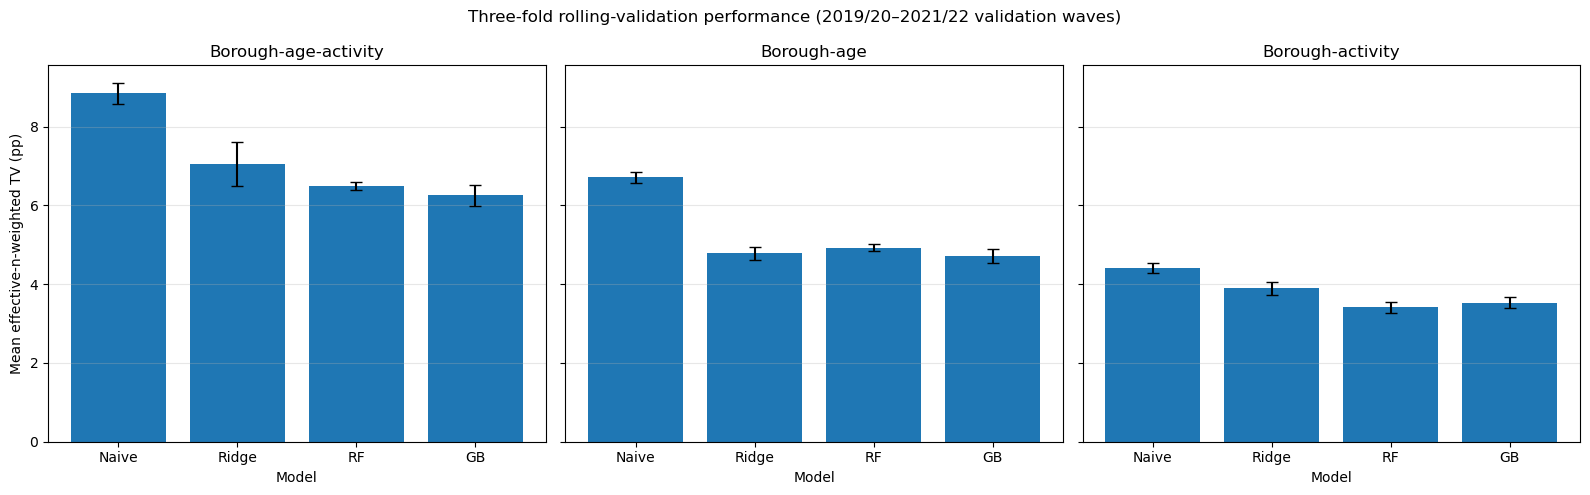

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/figures/figure_01_cv_model_comparison.png


In [11]:
task_order = list(
    TASK_CONFIG.keys()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharey=True,
)

for axis, task_name in zip(
    axes,
    task_order,
):
    subset = (
        model_summary.loc[
            model_summary[
                "task"
            ]
            == task_name
        ]
        .set_index("model")
        .reindex(
            MODEL_NAMES
        )
        .reset_index()
    )

    positions = np.arange(
        len(subset)
    )

    axis.bar(
        positions,
        subset[
            "mean_weighted_tv"
        ]
        * 100,
        yerr=(
            subset[
                "se_weighted_tv"
            ]
            * 100
        ),
        capsize=4,
    )

    axis.set_xticks(
        positions
    )

    axis.set_xticklabels(
        [
            "Naive",
            "Ridge",
            "RF",
            "GB",
        ]
    )

    axis.set_title(
        TASK_CONFIG[
            task_name
        ]["label"]
    )

    axis.set_xlabel(
        "Model"
    )

    axis.grid(
        axis="y",
        alpha=0.3,
    )

axes[0].set_ylabel(
    "Mean effective-n-weighted TV (pp)"
)

fig.suptitle(
    "Three-fold rolling-validation performance "
    "(2019/20–2021/22 validation waves)"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "figure_01_cv_model_comparison.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")

## 8 — Generate selected-model out-of-fold predictions

The formal model and hyperparameter choices are already frozen.

This module reruns each selected specification over the three rolling-validation folds to retain row-level out-of-fold predictions for downstream diagnostics and empirical forecast-uncertainty estimation.

In [12]:
selected_cv_prediction_parts = []

for _, selected_row in (
    selected_models.iterrows()
):
    task_name = (
        selected_row["task"]
    )

    model_name = (
        selected_row["model"]
    )

    parameters = json.loads(
        selected_row[
            "parameters_json"
        ]
    )

    panel = model_panels[
        task_name
    ]

    for fold in CV_FOLDS:
        (
            prediction_table,
            common_metrics,
            all_metrics,
        ) = evaluate_model_fold(
            task_name=task_name,
            panel=panel,
            model_name=model_name,
            parameters=parameters,
            train_end_year=(
                fold[
                    "train_end_year"
                ]
            ),
            validation_year=(
                fold[
                    "validation_year"
                ]
            ),
            phase=(
                "selected_rolling_validation"
            ),
        )

        prediction_table[
            "train_end_year"
        ] = fold[
            "train_end_year"
        ]

        prediction_table[
            "validation_year"
        ] = fold[
            "validation_year"
        ]

        selected_cv_prediction_parts.append(
            prediction_table
        )

selected_cv_predictions = (
    pd.concat(
        selected_cv_prediction_parts,
        ignore_index=True,
    )
)

print(
    f"Selected-model out-of-fold predictions: {len(selected_cv_predictions):,} rows"
)

Selected-model out-of-fold predictions: 3,158 rows


## 9 — Year 8 independent test

After model and hyperparameter selection is frozen, each family winner is refitted using Years 3–7 and evaluated on Year 8.

The common lag-available sample remains the formal comparison sample. Machine-learning models are also evaluated on all target-observed Year 8 cells to describe their additional coverage.

Year 8 results are diagnostic only and cannot change the selected model.

In [13]:
test_metric_rows = []
test_all_metric_rows = []
test_prediction_parts = []

for _, family_row in (
    family_best.iterrows()
):
    task_name = (
        family_row["task"]
    )

    model_name = (
        family_row["model"]
    )

    parameters = json.loads(
        family_row[
            "parameters_json"
        ]
    )

    (
        prediction_table,
        common_metrics,
        all_metrics,
    ) = evaluate_model_fold(
        task_name=task_name,
        panel=(
            model_panels[
                task_name
            ]
        ),
        model_name=model_name,
        parameters=parameters,
        train_end_year=7,
        validation_year=8,
        phase="Year 8 test",
    )

    prediction_table[
        "candidate_id"
    ] = family_row[
        "candidate_id"
    ]

    test_prediction_parts.append(
        prediction_table
    )

    test_metric_rows.append(
        {
            "task": task_name,
            "model": model_name,
            "candidate_id": (
                family_row[
                    "candidate_id"
                ]
            ),
            "parameters_json": (
                family_row[
                    "parameters_json"
                ]
            ),
            **common_metrics,
        }
    )

    test_all_metric_rows.append(
        {
            "task": task_name,
            "model": model_name,
            "candidate_id": (
                family_row[
                    "candidate_id"
                ]
            ),
            **all_metrics,
        }
    )

year8_predictions = (
    pd.concat(
        test_prediction_parts,
        ignore_index=True,
    )
)

year8_metrics = pd.DataFrame(
    test_metric_rows
)

year8_all_target_metrics = (
    pd.DataFrame(
        test_all_metric_rows
    )
)

selected_lookup = (
    selected_models[
        [
            "task",
            "model",
        ]
    ]
    .assign(
        selected_model=True
    )
)

year8_metrics = (
    year8_metrics
    .merge(
        selected_lookup,
        on=[
            "task",
            "model",
        ],
        how="left",
        validate="one_to_one",
    )
)

year8_metrics[
    "selected_model"
] = (
    year8_metrics[
        "selected_model"
    ]
    .fillna(False)
)

naive_test_scores = (
    year8_metrics.loc[
        year8_metrics[
            "model"
        ]
        == "Naive baseline",
        [
            "task",
            "weighted_tv",
        ],
    ]
    .rename(
        columns={
            "weighted_tv": (
                "naive_test_weighted_tv"
            )
        }
    )
)

year8_metrics = (
    year8_metrics
    .merge(
        naive_test_scores,
        on="task",
        how="left",
        validate="many_to_one",
    )
)

year8_metrics[
    "skill_vs_naive"
] = (
    1
    - (
        year8_metrics[
            "weighted_tv"
        ]
        / year8_metrics[
            "naive_test_weighted_tv"
        ]
    )
)

selected_year8_predictions = (
    year8_predictions
    .merge(
        selected_lookup,
        on=[
            "task",
            "model",
        ],
        how="left",
    )
)

selected_year8_predictions = (
    selected_year8_predictions.loc[
        selected_year8_predictions[
            "selected_model"
        ].fillna(False)
    ]
    .copy()
)

display(
    year8_metrics[
        [
            "task",
            "model",
            "selected_model",
            "observations",
            "weighted_tv",
            "mae",
            "rmse",
            "r2",
            "mean_error",
            "skill_vs_naive",
        ]
    ]
)

,task,model,selected_model,observations,weighted_tv,mae,rmse,r2,mean_error,skill_vs_naive
0,borough_activity,Gradient Boosting,False,96,0.029224,0.036942,0.049387,0.200797,-0.016531,0.235665
1,borough_activity,Naive baseline,False,96,0.038235,0.046031,0.058184,-0.109309,-0.011452,0.000000
2,borough_activity,Random Forest,True,96,0.031751,0.038406,0.050562,0.162296,-0.018387,0.169572
3,borough_activity,Ridge Regression,False,96,0.032350,0.037233,0.048995,0.213421,-0.013973,0.153895
4,borough_age,Gradient Boosting,True,253,0.050145,0.058303,0.102818,0.007578,-0.024228,0.244667
5,borough_age,Naive baseline,False,253,0.066388,0.073901,0.122772,-0.415003,-0.010435,0.000000
6,borough_age,Random Forest,False,253,0.048154,0.058435,0.100611,0.049728,-0.013363,0.274656
7,borough_age,Ridge Regression,False,253,0.051572,0.065992,0.104247,-0.020196,-0.015810,0.223182
8,borough_age_activity,Gradient Boosting,True,685,0.068281,0.084132,0.142189,-0.013644,-0.035411,0.234542
9,borough_age_activity,Naive baseline,False,685,0.089203,0.108923,0.184154,-0.700256,-0.010593,0.000000


## Figure 2 — Held-out Year 8 test

The Year 8 figure compares the four previously selected family specifications on the untouched historical wave.

A different Year 8 ranking does not reopen model selection.

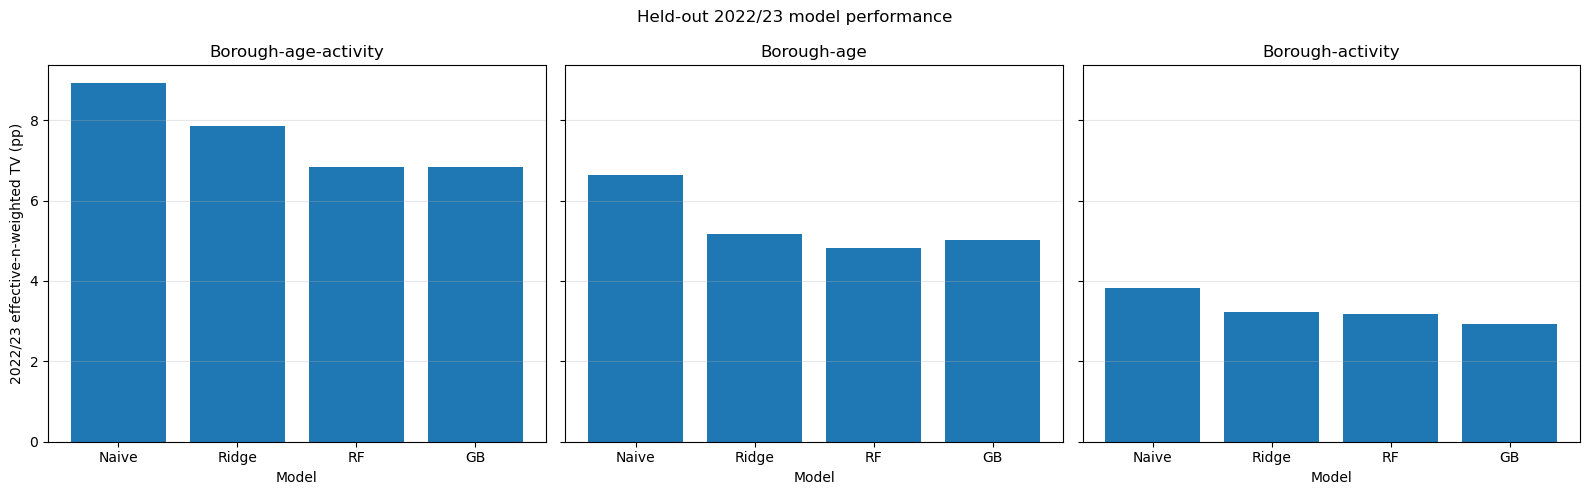

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/figures/figure_02_year8_model_comparison.png


In [14]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharey=True,
)

for axis, task_name in zip(
    axes,
    task_order,
):
    subset = (
        year8_metrics.loc[
            year8_metrics[
                "task"
            ]
            == task_name
        ]
        .set_index("model")
        .reindex(
            MODEL_NAMES
        )
        .reset_index()
    )

    positions = np.arange(
        len(subset)
    )

    axis.bar(
        positions,
        subset[
            "weighted_tv"
        ]
        * 100,
    )

    axis.set_xticks(
        positions
    )

    axis.set_xticklabels(
        [
            "Naive",
            "Ridge",
            "RF",
            "GB",
        ]
    )

    axis.set_title(
        TASK_CONFIG[
            task_name
        ]["label"]
    )

    axis.set_xlabel(
        "Model"
    )

    axis.grid(
        axis="y",
        alpha=0.3,
    )

axes[0].set_ylabel(
    "2022/23 effective-n-weighted TV (pp)"
)

fig.suptitle(
    "Held-out 2022/23 model performance"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "figure_02_year8_model_comparison.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")

## 10 — Year 8 subgroup, reliability and coverage diagnostics

The selected model for each task is examined across the subgroup dimensions relevant to that task and across effective-sample-size bands.

These diagnostics are particularly important for Q5 because the borough–age–activity panel contains many low-effective-n cells.

The diagnostics do not reselect the model.

In [15]:
def add_effective_n_band(
    data,
):
    result = data.copy()

    result[
        "effective_n_band"
    ] = pd.cut(
        result[
            "effective_n_parent_cell"
        ],
        bins=[
            -np.inf,
            5,
            10,
            30,
            np.inf,
        ],
        labels=[
            "<5",
            "5-10",
            "10-30",
            ">=30",
        ],
        right=False,
    )

    return result


def summarise_group_error(
    data,
    task_name,
    group_column,
    group_type,
):
    rows = []

    for group_value, subset in (
        data
        .groupby(
            group_column,
            observed=True,
            dropna=False,
        )
    ):
        available = (
            subset.loc[
                subset[
                    "predicted_rate"
                ].notna()
            ]
            .copy()
        )

        if len(available) == 0:
            continue

        metrics = (
            score_prediction_table(
                prediction_table=(
                    available
                ),
                common_only=False,
            )
        )

        rows.append(
            {
                "task": task_name,
                "group_type": group_type,
                "group": str(
                    group_value
                ),
                **metrics,
            }
        )

    return pd.DataFrame(
        rows
    )


selected_year8_diagnostic_data = (
    add_effective_n_band(
        selected_year8_predictions
    )
)

diagnostic_parts = []

for task_name in task_order:
    subset = (
        selected_year8_diagnostic_data.loc[
            selected_year8_diagnostic_data[
                "task"
            ]
            == task_name
        ]
        .copy()
    )

    diagnostic_parts.append(
        summarise_group_error(
            data=subset,
            task_name=task_name,
            group_column=(
                "effective_n_band"
            ),
            group_type=(
                "Effective sample size"
            ),
        )
    )

    diagnostic_parts.append(
        summarise_group_error(
            data=subset,
            task_name=task_name,
            group_column=(
                "small_cell"
            ),
            group_type=(
                "Small cell"
            ),
        )
    )

    if task_name in [
        "borough_age_activity",
        "borough_age",
    ]:
        diagnostic_parts.append(
            summarise_group_error(
                data=subset,
                task_name=task_name,
                group_column=(
                    "age_group"
                ),
                group_type=(
                    "Age group"
                ),
            )
        )

    if task_name in [
        "borough_age_activity",
        "borough_activity",
    ]:
        diagnostic_parts.append(
            summarise_group_error(
                data=subset,
                task_name=task_name,
                group_column=(
                    "activity_level_3cat_label"
                ),
                group_type=(
                    "Activity level"
                ),
            )
        )

selected_year8_diagnostics = (
    pd.concat(
        diagnostic_parts,
        ignore_index=True,
    )
)

display(
    selected_year8_diagnostics
)

,task,group_type,group,observations,weighted_tv,mae,rmse,weighted_rmse,r2,mean_error,clipped_predictions,clip_rate
0,borough_age_activity,Effective sample size,<5,265,0.091946,0.098197,0.193255,0.164371,-0.028297,-0.029444,0,0.0
1,borough_age_activity,Effective sample size,5-10,170,0.088929,0.092966,0.133230,0.126398,-0.146467,-0.045434,0,0.0
2,borough_age_activity,Effective sample size,10-30,201,0.068063,0.069144,0.088823,0.086564,0.030342,-0.034064,0,0.0
3,borough_age_activity,Effective sample size,>=30,80,0.056581,0.057700,0.075372,0.073840,-0.057572,-0.033521,0,0.0
4,borough_age_activity,Small cell,False,148,0.058425,0.059850,0.076869,0.075395,-0.024549,-0.026852,0,0.0
5,borough_age_activity,Small cell,True,568,0.081870,0.090638,0.157447,0.120730,-0.029753,-0.037115,0,0.0
6,borough_age_activity,Age group,16-24,93,0.088976,0.103615,0.168302,0.126099,-0.064588,-0.052265,0,0.0
7,borough_age_activity,Age group,25-34,96,0.059223,0.078257,0.114786,0.088213,-0.101402,-0.036343,0,0.0
8,borough_age_activity,Age group,35-44,96,0.064248,0.075024,0.108754,0.086704,-0.052308,-0.033398,0,0.0
9,borough_age_activity,Age group,45-54,96,0.066857,0.077295,0.114483,0.090360,0.062284,-0.031682,0,0.0


In [16]:
coverage_rows = []

for task_name in task_order:
    for phase_name, data in [
        (
            "Rolling validation",
            selected_cv_predictions.loc[
                selected_cv_predictions[
                    "task"
                ]
                == task_name
            ],
        ),
        (
            "Year 8 test",
            selected_year8_predictions.loc[
                selected_year8_predictions[
                    "task"
                ]
                == task_name
            ],
        ),
    ]:
        target_rows = int(
            data[
                TARGET
            ].notna().sum()
        )

        lag_rows = int(
            (
                data[
                    TARGET
                ].notna()
                & data[
                    "lag_1_available"
                ]
            ).sum()
        )

        predicted_rows = int(
            data[
                "predicted_rate"
            ].notna().sum()
        )

        coverage_rows.append(
            {
                "task": task_name,
                "phase": phase_name,
                "target_rows": target_rows,
                "lag_available_rows": (
                    lag_rows
                ),
                "predicted_rows": (
                    predicted_rows
                ),
                "common_sample_rate": (
                    lag_rows
                    / target_rows
                    if target_rows > 0
                    else np.nan
                ),
            }
        )

coverage_summary = (
    pd.DataFrame(
        coverage_rows
    )
)

display(
    coverage_summary
)

,task,phase,target_rows,lag_available_rows,predicted_rows,common_sample_rate
0,borough_age_activity,Rolling validation,2112,2027,2112,0.959754
1,borough_age_activity,Year 8 test,716,685,716,0.956704
2,borough_age,Rolling validation,758,749,758,0.988127
3,borough_age,Year 8 test,255,253,255,0.992157
4,borough_activity,Rolling validation,288,288,288,1.000000
5,borough_activity,Year 8 test,96,96,96,1.000000


## 11 — Selection-metric sensitivity

The official model-selection metric gives greater weight to cells with larger effective sample sizes.

Because the detailed Q5 panel contains many sparse cells, a sensitivity check repeats the candidate ranking using unweighted MAE across exactly the same rolling-validation predictions.

This check asks whether the selected model is mainly a consequence of the effective-n weighting rule. It does not alter the official effective-n-weighted selection.

In [17]:
unweighted_candidate_summary = (
    candidate_fold_metrics
    .groupby(
        [
            "task",
            "model",
            "candidate_id",
            "parameters_json",
        ],
        as_index=False,
    )
    .agg(
        folds=(
            "validation_year",
            "nunique",
        ),
        mean_unweighted_mae=(
            "common_mae",
            "mean",
        ),
        sd_unweighted_mae=(
            "common_mae",
            "std",
        ),
    )
)

unweighted_candidate_summary[
    "se_unweighted_mae"
] = (
    unweighted_candidate_summary[
        "sd_unweighted_mae"
    ]
    / np.sqrt(
        unweighted_candidate_summary[
            "folds"
        ]
    )
)

unweighted_family_rows = []

for (
    task_name,
    model_name,
), group in (
    unweighted_candidate_summary
    .groupby(
        [
            "task",
            "model",
        ]
    )
):
    row = (
        group
        .sort_values(
            [
                "mean_unweighted_mae",
                "se_unweighted_mae",
                "candidate_id",
            ]
        )
        .iloc[0]
        .copy()
    )

    unweighted_family_rows.append(
        row
    )

unweighted_family_best = (
    pd.DataFrame(
        unweighted_family_rows
    )
)

unweighted_winner_rows = []

for task_name, group in (
    unweighted_family_best
    .groupby("task")
):
    task_group = (
        group.copy()
    )

    task_group[
        "complexity_order"
    ] = task_group[
        "model"
    ].map(
        MODEL_COMPLEXITY_ORDER
    )

    winner = (
        task_group
        .sort_values(
            [
                "mean_unweighted_mae",
                "se_unweighted_mae",
                "complexity_order",
            ]
        )
        .iloc[0]
        .copy()
    )

    unweighted_winner_rows.append(
        winner
    )

unweighted_winners = (
    pd.DataFrame(
        unweighted_winner_rows
    )
)

metric_sensitivity = (
    selected_models[
        [
            "task",
            "model",
            "candidate_id",
            "mean_weighted_tv",
        ]
    ]
    .rename(
        columns={
            "model": (
                "official_weighted_model"
            ),
            "candidate_id": (
                "official_candidate_id"
            ),
        }
    )
    .merge(
        unweighted_winners[
            [
                "task",
                "model",
                "candidate_id",
                "mean_unweighted_mae",
            ]
        ].rename(
            columns={
                "model": (
                    "unweighted_model"
                ),
                "candidate_id": (
                    "unweighted_candidate_id"
                ),
            }
        ),
        on="task",
        how="left",
        validate="one_to_one",
    )
)

metric_sensitivity[
    "same_model"
] = (
    metric_sensitivity[
        "official_weighted_model"
    ]
    == metric_sensitivity[
        "unweighted_model"
    ]
)

display(
    metric_sensitivity
)

,task,official_weighted_model,official_candidate_id,mean_weighted_tv,unweighted_model,unweighted_candidate_id,mean_unweighted_mae,same_model
0,borough_activity,Random Forest,Random Forest_01,0.034092,Random Forest,Random Forest_01,0.038667,True
1,borough_age,Gradient Boosting,Gradient Boosting_04,0.047144,Gradient Boosting,Gradient Boosting_04,0.060243,True
2,borough_age_activity,Gradient Boosting,Gradient Boosting_05,0.062533,Gradient Boosting,Gradient Boosting_05,0.076830,True


## 12 — COVID-period model-development robustness

All three formal rolling-validation waves, Years 5–7, overlap with the period affected by COVID under the project definition. Year 5 also coincides with the transition to the later volunteering-question coding and weighting structure. The available six annual waves therefore cannot isolate a causal COVID effect from measurement change, ordinary time variation and sampling noise.

Two complementary robustness checks are used instead of adding a COVID indicator to the forecasting features.

First, a **post-overlap regime-transfer diagnostic** compares the model evidence from the COVID-overlap validation period with performance on the held-out Year 8 wave. The selected model and all family-specific candidates remain frozen before Year 8 is examined. This check assesses whether models developed during the overlap period retain predictive skill and broadly stable rankings after that period.

Second, a **transition-wave selection sensitivity** recalculates candidate rankings using only the Year 6 and Year 7 validation folds. This tests whether the formal three-fold model choice is sensitive to the inclusion of Year 5 validation evidence.

The second check excludes Year 5 only from the validation-score aggregation. Year 5 remains part of the expanding training data for the later validation folds, so this analysis does not estimate the effect of removing COVID-period observations from model training.

Neither check identifies a causal COVID effect, and neither can alter the official model or hyperparameter selection.

In [18]:
regime_transfer_family = (
    model_summary[
        [
            "task",
            "model",
            "candidate_id",
            "mean_weighted_tv",
            "skill_vs_naive",
        ]
    ]
    .rename(
        columns={
            "mean_weighted_tv": (
                "cv_mean_weighted_tv"
            ),
            "skill_vs_naive": (
                "cv_skill_vs_naive"
            ),
        }
    )
    .merge(
        year8_metrics[
            [
                "task",
                "model",
                "candidate_id",
                "weighted_tv",
                "skill_vs_naive",
                "selected_model",
            ]
        ].rename(
            columns={
                "weighted_tv": (
                    "year8_weighted_tv"
                ),
                "skill_vs_naive": (
                    "year8_skill_vs_naive"
                ),
            }
        ),
        on=[
            "task",
            "model",
            "candidate_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

regime_transfer_family[
    "cv_rank"
] = (
    regime_transfer_family
    .groupby(
        "task"
    )[
        "cv_mean_weighted_tv"
    ]
    .rank(
        method="min"
    )
    .astype(int)
)

regime_transfer_family[
    "year8_rank"
] = (
    regime_transfer_family
    .groupby(
        "task"
    )[
        "year8_weighted_tv"
    ]
    .rank(
        method="min"
    )
    .astype(int)
)

regime_transfer_family = (
    regime_transfer_family
    .sort_values(
        [
            "task",
            "cv_rank",
        ]
    )
    .reset_index(drop=True)
)

display(
    regime_transfer_family
)

year8_best = (
    regime_transfer_family
    .sort_values(
        [
            "task",
            "year8_weighted_tv",
        ]
    )
    .groupby(
        "task",
        as_index=False,
    )
    .first()
)

year8_best = (
    year8_best[
        [
            "task",
            "model",
            "year8_weighted_tv",
        ]
    ]
    .rename(
        columns={
            "model": (
                "year8_best_model"
            ),
            "year8_weighted_tv": (
                "year8_best_weighted_tv"
            ),
        }
    )
)

selected_transfer = (
    regime_transfer_family.loc[
        regime_transfer_family[
            "selected_model"
        ]
    ]
    .copy()
)

regime_transfer_summary = (
    selected_transfer[
        [
            "task",
            "model",
            "candidate_id",
            "cv_mean_weighted_tv",
            "cv_skill_vs_naive",
            "year8_weighted_tv",
            "year8_skill_vs_naive",
            "year8_rank",
        ]
    ]
    .rename(
        columns={
            "model": (
                "official_model"
            ),
            "candidate_id": (
                "official_candidate_id"
            ),
        }
    )
    .merge(
        year8_best,
        on="task",
        how="left",
        validate="one_to_one",
    )
)

regime_transfer_summary[
    "same_year8_best_model"
] = (
    regime_transfer_summary[
        "official_model"
    ]
    == regime_transfer_summary[
        "year8_best_model"
    ]
)

regime_transfer_summary[
    "selected_minus_year8_best_tv"
] = (
    regime_transfer_summary[
        "year8_weighted_tv"
    ]
    - regime_transfer_summary[
        "year8_best_weighted_tv"
    ]
)

regime_transfer_summary[
    "skill_change"
] = (
    regime_transfer_summary[
        "year8_skill_vs_naive"
    ]
    - regime_transfer_summary[
        "cv_skill_vs_naive"
    ]
)

display(
    regime_transfer_summary
)

,task,model,candidate_id,cv_mean_weighted_tv,cv_skill_vs_naive,year8_weighted_tv,year8_skill_vs_naive,selected_model,cv_rank,year8_rank
0,borough_activity,Random Forest,Random Forest_01,0.034092,0.227290,0.031751,0.169572,True,1,2
1,borough_activity,Gradient Boosting,Gradient Boosting_04,0.035299,0.199948,0.029224,0.235665,False,2,1
2,borough_activity,Ridge Regression,Ridge Regression_05,0.038931,0.117620,0.032350,0.153895,False,3,3
3,borough_activity,Naive baseline,Naive baseline_01,0.044120,0.000000,0.038235,0.000000,False,4,4
4,borough_age,Gradient Boosting,Gradient Boosting_04,0.047144,0.297823,0.050145,0.244667,True,1,2
5,borough_age,Ridge Regression,Ridge Regression_07,0.047824,0.287695,0.051572,0.223182,False,2,3
6,borough_age,Random Forest,Random Forest_03,0.049274,0.266109,0.048154,0.274656,False,3,1
7,borough_age,Naive baseline,Naive baseline_01,0.067140,0.000000,0.066388,0.000000,False,4,4
8,borough_age_activity,Gradient Boosting,Gradient Boosting_05,0.062533,0.292849,0.068281,0.234542,True,1,1
9,borough_age_activity,Random Forest,Random Forest_05,0.064875,0.266368,0.068466,0.232469,False,2,2


,task,official_model,official_candidate_id,cv_mean_weighted_tv,cv_skill_vs_naive,year8_weighted_tv,year8_skill_vs_naive,year8_rank,year8_best_model,year8_best_weighted_tv,same_year8_best_model,selected_minus_year8_best_tv,skill_change
0,borough_activity,Random Forest,Random Forest_01,0.034092,0.227290,0.031751,0.169572,2,Gradient Boosting,0.029224,False,0.002527,-0.057718
1,borough_age,Gradient Boosting,Gradient Boosting_04,0.047144,0.297823,0.050145,0.244667,2,Random Forest,0.048154,False,0.001991,-0.053156
2,borough_age_activity,Gradient Boosting,Gradient Boosting_05,0.062533,0.292849,0.068281,0.234542,1,Gradient Boosting,0.068281,True,0.000000,-0.058307


In [19]:
LATER_VALIDATION_YEARS = [
    6,
    7,
]

transition_candidate_summary = (
    candidate_fold_metrics.loc[
        candidate_fold_metrics[
            "validation_year"
        ].isin(
            LATER_VALIDATION_YEARS
        )
    ]
    .groupby(
        [
            "task",
            "model",
            "candidate_id",
            "parameters_json",
        ],
        as_index=False,
    )
    .agg(
        folds=(
            "validation_year",
            "nunique",
        ),
        mean_weighted_tv=(
            "common_weighted_tv",
            "mean",
        ),
        sd_weighted_tv=(
            "common_weighted_tv",
            "std",
        ),
        worst_weighted_tv=(
            "common_weighted_tv",
            "max",
        ),
        mean_mae=(
            "common_mae",
            "mean",
        ),
    )
)

transition_candidate_summary[
    "se_weighted_tv"
] = (
    transition_candidate_summary[
        "sd_weighted_tv"
    ]
    / np.sqrt(
        transition_candidate_summary[
            "folds"
        ]
    )
)

if not transition_candidate_summary[
    "folds"
].eq(2).all():
    raise ValueError(
        "Every transition-wave candidate must contain exactly two validation folds"
    )

transition_family_rows = []

for (
    task_name,
    model_name,
), group in (
    transition_candidate_summary
    .groupby(
        [
            "task",
            "model",
        ]
    )
):
    selected_row = (
        group
        .sort_values(
            [
                "mean_weighted_tv",
                "se_weighted_tv",
                "candidate_id",
            ]
        )
        .iloc[0]
        .copy()
    )

    transition_family_rows.append(
        selected_row
    )

transition_family_best = (
    pd.DataFrame(
        transition_family_rows
    )
    .reset_index(drop=True)
)

transition_selected_rows = []

for task_name, group in (
    transition_family_best
    .groupby(
        "task"
    )
):
    task_group = (
        group.copy()
    )

    task_group[
        "complexity_order"
    ] = task_group[
        "model"
    ].map(
        MODEL_COMPLEXITY_ORDER
    )

    selected_row = (
        task_group
        .sort_values(
            [
                "mean_weighted_tv",
                "se_weighted_tv",
                "complexity_order",
            ]
        )
        .iloc[0]
        .copy()
    )

    transition_selected_rows.append(
        selected_row
    )

transition_selected_models = (
    pd.DataFrame(
        transition_selected_rows
    )
    .reset_index(drop=True)
)

official_later_scores = (
    selected_models[
        [
            "task",
            "model",
            "candidate_id",
        ]
    ]
    .merge(
        transition_candidate_summary[
            [
                "task",
                "model",
                "candidate_id",
                "mean_weighted_tv",
            ]
        ],
        on=[
            "task",
            "model",
            "candidate_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .rename(
        columns={
            "mean_weighted_tv": (
                "official_candidate_later_tv"
            )
        }
    )
)

transition_wave_sensitivity = (
    selected_models[
        [
            "task",
            "model",
            "candidate_id",
            "mean_weighted_tv",
        ]
    ]
    .rename(
        columns={
            "model": (
                "official_model"
            ),
            "candidate_id": (
                "official_candidate_id"
            ),
            "mean_weighted_tv": (
                "official_three_fold_tv"
            ),
        }
    )
    .merge(
        official_later_scores[
            [
                "task",
                "official_candidate_later_tv",
            ]
        ],
        on="task",
        how="left",
        validate="one_to_one",
    )
    .merge(
        transition_selected_models[
            [
                "task",
                "model",
                "candidate_id",
                "mean_weighted_tv",
            ]
        ].rename(
            columns={
                "model": (
                    "later_wave_model"
                ),
                "candidate_id": (
                    "later_wave_candidate_id"
                ),
                "mean_weighted_tv": (
                    "later_wave_best_tv"
                ),
            }
        ),
        on="task",
        how="left",
        validate="one_to_one",
    )
)

transition_wave_sensitivity[
    "same_model"
] = (
    transition_wave_sensitivity[
        "official_model"
    ]
    == transition_wave_sensitivity[
        "later_wave_model"
    ]
)

transition_wave_sensitivity[
    "same_candidate"
] = (
    transition_wave_sensitivity[
        "official_candidate_id"
    ]
    == transition_wave_sensitivity[
        "later_wave_candidate_id"
    ]
)

transition_wave_sensitivity[
    "official_minus_later_best_tv"
] = (
    transition_wave_sensitivity[
        "official_candidate_later_tv"
    ]
    - transition_wave_sensitivity[
        "later_wave_best_tv"
    ]
)

display(
    transition_wave_sensitivity
)

,task,official_model,official_candidate_id,official_three_fold_tv,official_candidate_later_tv,later_wave_model,later_wave_candidate_id,later_wave_best_tv,same_model,same_candidate,official_minus_later_best_tv
0,borough_activity,Random Forest,Random Forest_01,0.034092,0.034239,Random Forest,Random Forest_01,0.034239,True,True,0.000000
1,borough_age,Gradient Boosting,Gradient Boosting_04,0.047144,0.046507,Ridge Regression,Ridge Regression_07,0.046239,False,False,0.000267
2,borough_age_activity,Gradient Boosting,Gradient Boosting_05,0.062533,0.060442,Gradient Boosting,Gradient Boosting_02,0.059936,True,False,0.000507


## 13 — Save model-selection outputs and run final checks

The saved outputs contain the complete rolling-validation evidence, selected hyperparameters, Year 8 independent evaluation and model-selection sensitivity checks.

No future years are generated in this notebook.

In [20]:
output_tables = {
    "q5_cv_candidate_fold_metrics.csv":
        candidate_fold_metrics,
    "q5_cv_candidate_summary.csv":
        candidate_summary,
    "q5_cv_model_summary.csv":
        model_summary,
    "q5_selected_models.csv":
        selected_models,
    "q5_selected_cv_predictions.csv":
        selected_cv_predictions,
    "q5_year8_model_metrics.csv":
        year8_metrics,
    "q5_year8_all_target_metrics.csv":
        year8_all_target_metrics,
    "q5_year8_all_model_predictions.csv":
        year8_predictions,
    "q5_year8_selected_predictions.csv":
        selected_year8_predictions,
    "q5_year8_selected_diagnostics.csv":
        selected_year8_diagnostics,
    "q5_prediction_coverage_summary.csv":
        coverage_summary,
    "q5_metric_weighting_sensitivity.csv":
        metric_sensitivity,
    "q5_covid_regime_transfer_family.csv":
        regime_transfer_family,
    "q5_covid_regime_transfer_summary.csv":
        regime_transfer_summary,
    "q5_transition_wave_candidate_summary.csv":
        transition_candidate_summary,
    "q5_transition_wave_selection_sensitivity.csv":
        transition_wave_sensitivity,
}

for filename, dataframe in (
    output_tables.items()
):
    output_path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print(f"Saved table: {output_path}")

Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_cv_candidate_fold_metrics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_cv_candidate_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_cv_model_summary.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_selected_models.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_selected_cv_predictions.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_year8_model_metrics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_year8_all_target_metrics.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_year8_all_model_predictions.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables/q5_year8_selected_predictions

In [21]:
selection_summary = {
    "target": TARGET,
    "historical_years": (
        HISTORICAL_YEARS
    ),
    "validation_years": [
        fold[
            "validation_year"
        ]
        for fold in CV_FOLDS
    ],
    "test_year": TEST_YEAR,
    "primary_metric": (
        "mean effective-sample-size-weighted TV-equivalent absolute error"
    ),
    "random_state": RANDOM_STATE,
    "selected_tasks": {},
}

for _, row in (
    selected_models.iterrows()
):
    task_name = (
        row["task"]
    )

    selection_summary[
        "selected_tasks"
    ][task_name] = {
        "model": row[
            "model"
        ],
        "parameters": json.loads(
            row[
                "parameters_json"
            ]
        ),
        "mean_cv_weighted_tv": (
            float(
                row[
                    "mean_weighted_tv"
                ]
            )
        ),
        "se_cv_weighted_tv": (
            float(
                row[
                    "se_weighted_tv"
                ]
            )
        ),
        "numeric_features": (
            FEATURE_CONFIG[
                task_name
            ]["numeric"]
        ),
        "categorical_features": (
            FEATURE_CONFIG[
                task_name
            ]["categorical"]
        ),
    }

summary_path = (
    OUTPUT_DIR
    / "q5_model_selection_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        selection_summary,
        file,
        indent=2,
    )

print(f"Saved summary: {summary_path}")

Saved summary: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/q5_model_selection_summary.json


In [22]:
expected_validation_years = {
    5,
    6,
    7,
}

if set(
    candidate_fold_metrics[
        "validation_year"
    ].unique()
) != expected_validation_years:
    raise ValueError(
        "Unexpected rolling-validation years"
    )

if TEST_YEAR in set(
    candidate_fold_metrics[
        "validation_year"
    ]
):
    raise ValueError(
        "Year 8 entered model selection"
    )

fold_counts = (
    candidate_fold_metrics
    .groupby(
        [
            "task",
            "model",
            "candidate_id",
        ]
    )
    .size()
)

if not fold_counts.eq(3).all():
    raise ValueError(
        "A model candidate does not contain exactly three folds"
    )

if len(
    selected_models
) != len(
    TASK_CONFIG
):
    raise ValueError(
        "Exactly one model must be selected for each task"
    )

if not year8_predictions[
    "year"
].eq(
    TEST_YEAR
).all():
    raise ValueError(
        "Year 8 predictions contain an unexpected year"
    )

if selected_cv_predictions[
    "year"
].max() > 7:
    raise ValueError(
        "Model-selection predictions contain Year 8 or a future year"
    )

if year8_predictions[
    "year"
].max() > 8:
    raise ValueError(
        "This notebook generated a future-year prediction"
    )

if candidate_summary[
    "mean_weighted_tv"
].isna().any():
    raise ValueError(
        "A candidate has a missing primary validation score"
    )

if not selected_models[
    "model"
].isin(
    MODEL_NAMES
).all():
    raise ValueError(
        "An invalid model was selected"
    )

print("All Q5 model-comparison checks passed.")
print(f"Figures saved to: {FIGURE_DIR}")
print(f"Tables saved to: {TABLE_DIR}")

All Q5 model-comparison checks passed.
Figures saved to: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/figures
Tables saved to: /Users/zsh/Downloads/PROJECT/code/q4_model_comparison_outputs/tables
